# Data Exploration

In this notebook, we visualize the dataset to get some understanding into the structures and class distribution of the **ECG5000 training dataset**. 

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set_theme(style="whitegrid")

### Load Dataset

Here we load the training dataset both the original with 5 classes and the processed with 2 classes. 

In [16]:
def load_dataset(data_dir, filename):
    """Loads a specific txt file into X (features) and y (labels)."""
    path = os.path.join(data_dir, filename)
    data = np.loadtxt(path)
    
    # Col 0 is Label, Cols 1-140 are Features
    y = data[:, 0].astype(int)
    X = data[:, 1:]
    return X, y

# RAW DATA (5 Classes)
X_raw, y_raw = load_dataset('../data/raw', 'ECG5000_TRAIN.txt')

# PROCESSED DATA (2 Classes) - if data was processed to have only 2 classes
try:
    X_bin, y_bin = load_dataset('../data/processed', 'ECG5000_TRAIN.txt')
    print("Binary data loaded successfully.")
except:
    print("Binary data not found. Run src/data_processing.py / the Data Processing section of the src/notebooks/main.ipynb notebook first.")
    X_bin, y_bin = None, None

Binary data loaded successfully.


### Visualization

In the cells that follow we visualize the dataset class distribution, individual samples from all the classes, the Mean (Average) signal and the Standard Deviation (Variance) from the processed classes.

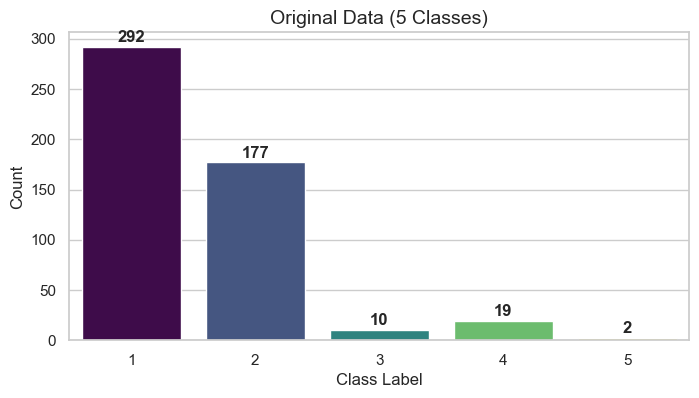

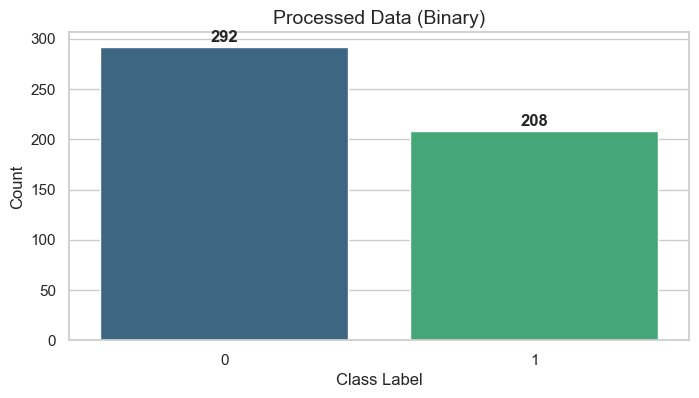

In [17]:
def plot_class_distribution(y, title="Class Distribution"):
    """
    Plots a bar chart of the number of samples per class.
    """
    plt.figure(figsize=(8, 4))
    
    # Count classes
    unique, counts = np.unique(y, return_counts=True)
    
    # Create bar plot
    ax = sns.barplot(x=unique, y=counts, palette="viridis", hue=unique, legend=False)
    
    plt.title(title, fontsize=14)
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    
    # Add numbers on top of bars
    for i, count in enumerate(counts):
        ax.text(i, count + 5, str(count), ha='center', fontweight='bold')
        
    plt.show()

plot_class_distribution(y_raw, "Original Data (5 Classes)")
if y_bin is not None:
    plot_class_distribution(y_bin, "Processed Data (Binary)")

The plots above show the class distribution of the **ECG5000 Dataset**. 
The first plot visualizes the raw / unprocessed dataset. Visualization shows **high class imbalance** as only 2 Data points have the class/label of 5. 
The second plot shows a much improved dataset. After data processing classes 2-5 are combined to become the unhealty/abnormal class and class 1 remains the Healthy or normal class. for consistency with pytorch which prioritizes 0 indexes, the **normal class** was renamed to **class 0** and the **abnormal class** was renamed to **class 1**

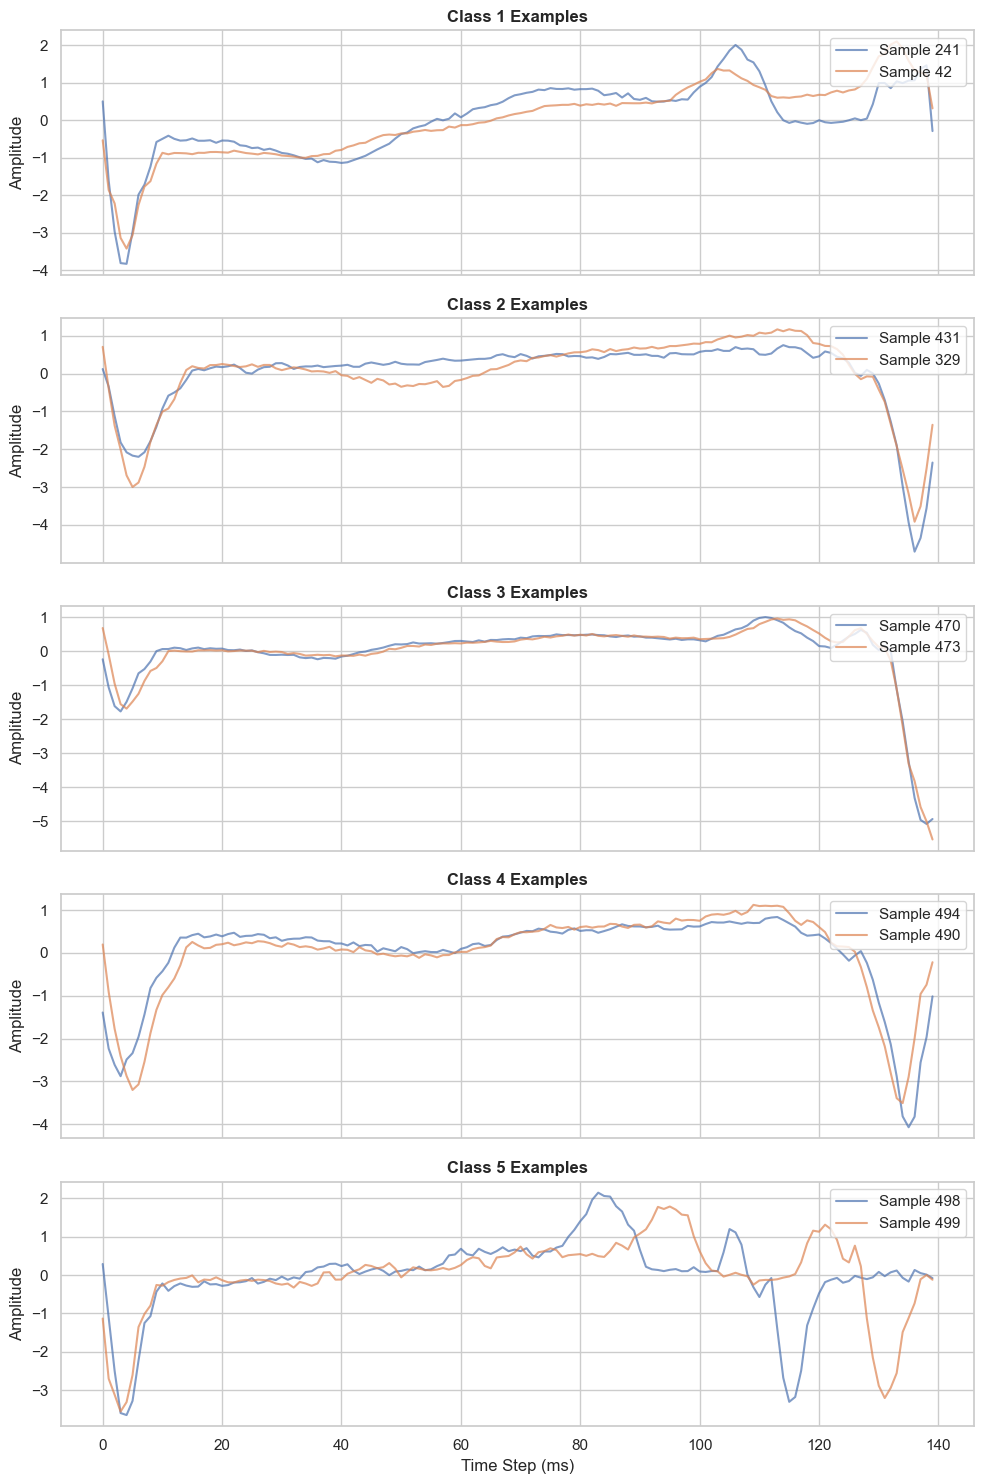

In [ ]:
def plot_signal_examples(X, y, num_samples=2):
    """
    Plots 'num_samples' random examples from EACH class side-by-side.
  
    """
    classes = np.unique(y)
    n_classes = len(classes)
    
    fig, axes = plt.subplots(n_classes, 1, figsize=(10, 3*n_classes), sharex=True)
    if n_classes == 1: axes = [axes] # Handle single class case
    
    for i, cls in enumerate(classes):
        # Get all samples for this class
        idxs = np.where(y == cls)[0]
        
        # Pick random samples
        random_idxs = np.random.choice(idxs, num_samples, replace=False)
        
        # Plot them
        for ridx in random_idxs:
            axes[i].plot(X[ridx], alpha=0.7, label=f"Sample {ridx}")
            
        axes[i].set_title(f"Class {cls} Examples", fontweight='bold')
        axes[i].set_ylabel("Amplitude")
        axes[i].legend(loc='upper right')
        
    plt.xlabel("Time Step (ms)")
    plt.tight_layout()
    plt.show()

plot_signal_examples(X_raw, y_raw)

The plot above visualizes *random samples* from each of the **5 classes** present in the **raw/unprocessed ECG5000 dataset**.
The default value of 2 random samples was set because 1 of the classes (class 5) has only 2 data points in the training set. 

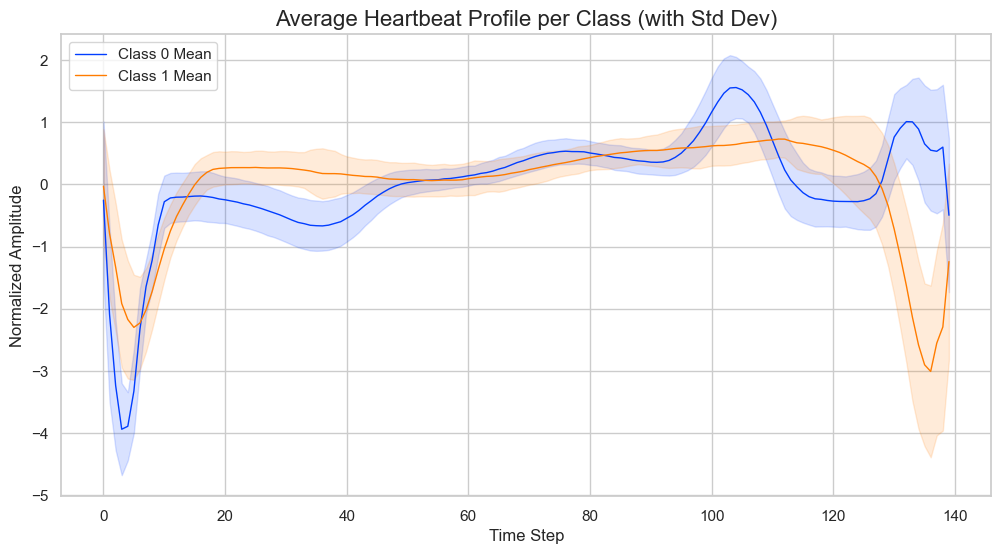

In [13]:
def plot_average_signals(X, y):
    """
    Plots the MEAN signal for each class with STD DEV shading.
    """
    classes = np.unique(y)
    plt.figure(figsize=(12, 6))
    
    colors = sns.color_palette("bright", len(classes))
    
    for i, cls in enumerate(classes):
        # Get data for class
        X_cls = X[y == cls]
        
        # Calculate Mean and Std
        mean_sig = np.mean(X_cls, axis=0)
        std_sig = np.std(X_cls, axis=0)
        
        # Plot Mean
        time_steps = np.arange(len(mean_sig))
        plt.plot(time_steps, mean_sig, label=f"Class {cls} Mean", color=colors[i], linewidth=1)
        
        # Fill Std Dev (Variance)
        plt.fill_between(time_steps, mean_sig - std_sig, mean_sig + std_sig, color=colors[i], alpha=0.15)
        
    plt.title("Average Heartbeat Profile per Class (with Std Dev)", fontsize=16)
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Amplitude")
    plt.legend()
    plt.show()

if X_bin is not None:
    plot_average_signals(X_bin, y_bin)

The plot above shows The average shape of a "Normal" heartbeat (Class 0, Blue) vs. an "Abnormal" one (Class 1, Orange). We aim to view the feature seperation and determine if the a model will perform well on the dataset. This shows (visually) that the classes are distinguishable and further validates the feasibility of implementing a binary classifier. 